---
title: Choosing an inference method
short_title: 13 · Inference benchmark
subtitle: Guides and site-based approximations for a latent GP with an extreme-value likelihood
---

# Which approximation should carry the GP?

Notebooks 07-09 all face the same computational problem: a **Gaussian-process
prior** over a spatial field, observed through a **non-Gaussian likelihood**
(the GEV). There is no conjugate answer, so every one of them reaches for an
approximation — 07 a Laplace fit, 08 and 09 mean-field variational inference.

That choice is not innocuous. Warm-starting 08 and 09 from 07's posterior moved
their ELBO by less than 0.05% and left the 100-year return-level intervals
unchanged at 9-10 degC, against 07's 2.7 -- so whatever separates those
notebooks, it is not how hard the optimiser worked. It is the approximation
itself.

So this notebook benchmarks the alternatives `pyrox-gp` offers, on one common
problem, and asks three questions:

1. Do structured variational guides recover what mean-field throws away?
2. How do the site-based approximations (Laplace, Gauss-Newton, posterior
   linearisation, EP) compare on accuracy and cost?
3. Does the GEV's **bounded upper tail** favour one family over the other?

The answer to (3) turns out to be the practical headline.


In [1]:
from __future__ import annotations

import time
import warnings

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
jax.config.update("jax_enable_x64", True)   # GP linear algebra wants float64
sns.set_theme(style="whitegrid", context="notebook")

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

from gaussx import GaussHermiteIntegrator, DenseSolver
import pyrox_gp as P
from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

## A compatibility shim

Two of the guides cannot be trained as shipped. `gaussx.safe_cholesky` retries
its Cholesky with growing jitter inside a `jax.lax.while_loop`, and a
`while_loop` **has no reverse-mode derivative** — so the forward ELBO evaluates
happily while `grad` raises. It is reached from `MeanFieldGuide.predict` and
`FullRankGuide.predict` via `_svgp_predict_unwhitened`.

The patch below swaps in a single Cholesky with fixed jitter, which is what most
GP libraries do and which differentiates fine. It is a **temporary shim**, not a
recommendation: the real fix belongs upstream in `gaussx`, where the retry loop
should be a bounded `fori_loop`/`scan` rather than a `while_loop`.


In [2]:
import gaussx._linalg._safe_cholesky as _sc
import sys


def _fixed_jitter_cholesky(operator, *args, **kwargs):
    """Reverse-differentiable stand-in for gaussx.safe_cholesky."""
    A = operator.as_matrix()
    eye = jnp.eye(A.shape[0], dtype=A.dtype)
    return jnp.linalg.cholesky(A + 1e-6 * eye)


_sc.safe_cholesky = _fixed_jitter_cholesky
for _name, _mod in list(sys.modules.items()):
    if _name.startswith(("gaussx", "pyrox_gp")) and hasattr(_mod, "safe_cholesky"):
        _mod.safe_cholesky = _fixed_jitter_cholesky
print("patched gaussx.safe_cholesky -> fixed-jitter (reverse-differentiable)")

patched gaussx.safe_cholesky -> fixed-jitter (reverse-differentiable)


## One problem, every method

To compare approximations we need a problem they all solve *identically*, so any
difference is the approximation and not the model.

Each of the 107 stations contributes **one** observation: the highest
temperature in its entire record. A record maximum is itself an extreme-value
variable, and using one observation per station keeps the latent field the only
unknown — every method here then works on the same 107-dimensional posterior.

The GEV scale and shape are **fixed**, taken from notebook 07's spatial fit.
That is not the model you would ship; it is the control that makes the
comparison fair -- with them held still, the latent field is the only thing
any of these methods is approximating.


In [3]:
maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
S = stations.shape[0]
y_np = np.nanmax(maxima, axis=1)                 # record maximum per station
X_np = (stations - stations.mean(0)) / stations.std(0)
X, y = jnp.asarray(X_np), jnp.asarray(y_np)

# Take sigma and xi from notebook 07's fitted spatial GEV rather than refitting
# here. A constant-location MLE on these record maxima is badly misspecified --
# they span 23-47 degC precisely *because* the location varies in space, which
# is the thing we are asking the GP to learn -- and it runs away to a degenerate
# sigma. Notebook 07 already estimated them with the location free to vary.
from spatial_extremes import results

_sp = results.load_fit("spatial_gp_mu", expect_real=is_real)
if _sp is not None:
    SIGMA, XI_FIT = float(_sp["sigma_med"]), float(_sp["xi_med"])
    print(results.describe_fit(_sp))
else:
    SIGMA, XI_FIT = 2.0, -0.20
    print("no cached notebook-07 fit - using sigma = 2.0, xi = -0.20")
M0 = float(np.mean(y_np))

print("source:", "REAL CDS" if is_real else "synthetic",
      f"| {S} stations | record maxima {y_np.min():.1f}-{y_np.max():.1f} degC")
print(f"fixed scale/shape: sigma = {SIGMA:.2f} degC, xi = {XI_FIT:+.3f}")
print(f"prior mean location m0 = {M0:.2f} degC")

warm start <- notebooks/03_spatial_gev/07_spatial_gp_mu.ipynb @ 28243b1 (2026-08-21T17:37:52+00:00)
source: REAL CDS | 107 stations | record maxima 23.4-47.2 degC
fixed scale/shape: sigma = 1.96 degC, xi = -0.205
prior mean location m0 = 41.04 degC


### The tail that bites

With $\xi<0$ the GEV has a **finite upper bound** $\mu + \sigma/|\xi|$: the model
asserts temperatures above it are impossible. That single fact drives most of
what follows, so it is worth seeing before we start.

We run the main benchmark at $\xi=0$ — the **Gumbel** limit, unbounded above,
where every method is on equal footing — and then switch the bound back on in
the last section to see which methods survive it.


In [4]:
bound_fit = M0 + SIGMA / abs(XI_FIT)
print(f"at the MLE, upper bound = {bound_fit:.1f} degC vs hottest record "
      f"{y_np.max():.1f} degC -> {'inside' if bound_fit > y_np.max() else 'VIOLATED'}")

XI_MAIN = 0.0                                    # Gumbel for the main comparison
lik = P.DistLikelihood(
    lambda f: GEV(loc=f + M0, scale=SIGMA, concentration=XI_MAIN))
integrator = GaussHermiteIntegrator(order=20)    # for the non-conjugate ELBO
SOLVER = DenseSolver()

def kernel():
    return P.Matern(nu=1.5, init_variance=9.0, init_lengthscale=0.9)

# Zero-mean latent field; the offset M0 lives in the likelihood link, so the
# guides, the site-based strategies and NUTS all work on one common scale.
sparse = P.SparseGPPrior(kernel=kernel(), Z=X, solver=SOLVER)
dense = P.GPPrior(kernel=kernel(), X=X, solver=SOLVER)
print(f"latent field: Matern-3/2 over standardised (lon, lat), "
      f"{S} inducing points")

at the MLE, upper bound = 50.6 degC vs hottest record 47.2 degC -> inside
latent field: Matern-3/2 over standardised (lon, lat), 107 inducing points


## The reference answer

Nothing above is a *ground truth*. To judge the approximations we need one, so
we run NUTS on the same model — 107 latent values, no approximation beyond Monte
Carlo error. It is affordable precisely because we fixed everything else.


In [5]:
def latent_model(obs=None):
    f = P.gp_sample("f", P.GPPrior(kernel=kernel(), X=X), whitened=True)
    numpyro.sample("y", GEV(loc=f + M0, scale=SIGMA, concentration=XI_MAIN),
                   obs=obs)

t0 = time.time()
mcmc = MCMC(NUTS(latent_model, target_accept_prob=0.9,
                 init_strategy=init_to_value(values={"f_u": jnp.zeros(S)})),
            num_warmup=500, num_samples=500, num_chains=1, progress_bar=False)
mcmc.run(jr.PRNGKey(0), obs=y)
t_nuts = time.time() - t0
ref = np.asarray(mcmc.get_samples()["f"])
ref_mean, ref_sd = ref.mean(0), ref.std(0)
print(f"NUTS reference: {t_nuts:.1f}s | mean f {ref_mean.mean():.2f} degC "
      f"| mean posterior sd {ref_sd.mean():.3f} degC")

NUTS reference: 8.3s | mean f -1.43 degC | mean posterior sd 1.001 degC


## Family A — variational guides

The first family posits a Gaussian $q(u)$ over the inducing values and maximises
an ELBO. The guides differ only in how much structure that Gaussian is allowed:

- **MeanField** — diagonal covariance. Field values are forced *independent*,
  which is precisely what a smooth spatial field is not.
- **FullRank** — a dense Cholesky factor: every pair of stations may covary.
- **Whitened** — full rank, but parameterised in the prior's whitened
  coordinates, which conditions the optimisation far better.

All three optimise the same objective with the same budget, so the ELBO they
reach is directly comparable — higher is a strictly tighter bound.


In [6]:
def train_guide(cls, steps=800, lr=2e-2):
    guide = cls.init(S, scale=1.0, solver=SOLVER)
    opt = optax.adam(lr)
    state = opt.init(eqx.filter(guide, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(g, s):
        loss, grads = eqx.filter_value_and_grad(
            lambda gg: -P.svgp_elbo(sparse, gg, lik, X, y, integrator=integrator)
        )(g)
        updates, s = opt.update(grads, s)
        return eqx.apply_updates(g, updates), s, loss

    t0, trace = time.time(), []
    for _ in range(steps):
        guide, state, loss = step(guide, state)
        trace.append(float(loss))
    return guide, np.array(trace), time.time() - t0


results = {}
for name, cls in [("MeanField", P.MeanFieldGuide),
                  ("FullRank", P.FullRankGuide),
                  ("Whitened", P.WhitenedGuide)]:
    guide, trace, dt = train_guide(cls)
    K_zz_op, K_xz, K_xx_diag = sparse.predictive_blocks(X)
    mean, var = guide.predict(K_xz, K_zz_op, K_xx_diag)
    results[name] = {"family": "variational", "elbo": -trace[-1], "time": dt,
                     "mean": np.asarray(mean), "sd": np.asarray(jnp.sqrt(var)),
                     "trace": trace}
    print(f"{name:11s} ELBO {-trace[-1]:10.2f} | {dt:5.1f}s")

MeanField   ELBO    -724.64 |  11.9s


FullRank    ELBO    -631.82 |  12.1s


Whitened    ELBO    -349.64 |   3.6s


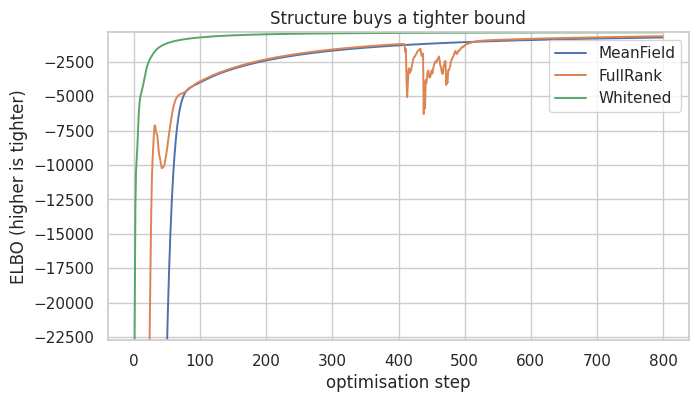

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for name in ("MeanField", "FullRank", "Whitened"):
    ax.plot(-results[name]["trace"], lw=1.4, label=name)
ax.set(xlabel="optimisation step", ylabel="ELBO (higher is tighter)",
       title="Structure buys a tighter bound")
lo = min(-r["trace"][50] for r in results.values())
ax.set_ylim(lo, max(-r["trace"][-1] for r in results.values()) + 5)
ax.legend()
plt.show()

## Family B — site-based approximations

The second family never optimises an ELBO. Each method replaces the awkward
likelihood with a **Gaussian site** per observation and then conditions exactly,
differing in how that site is chosen:

- **Laplace** — a second-order fit at the posterior mode.
- **Gauss-Newton** — the same idea with a curvature approximation that drops the
  awkward term, usually much cheaper.
- **Posterior linearisation** — linearises the likelihood about the current
  posterior rather than the mode, iterating to a fixed point.
- **Expectation propagation** — matches moments site by site, generally the most
  accurate of the four and the most expensive.
- **Quasi-Newton** — a BFGS-style mode search (needs the `[optax]` extra).

They need no integrator, no learning rate and no step budget: they simply run to
convergence.


In [8]:
STRATEGIES = [("Laplace", P.LaplaceInference),
              ("GaussNewton", P.GaussNewtonInference),
              ("PosteriorLin", P.PosteriorLinearization),
              ("EP", P.ExpectationPropagation),
              ("QuasiNewton", P.QuasiNewtonInference)]

for name, cls in STRATEGIES:
    try:
        t0 = time.time()
        cond = dense.condition_nongauss(lik, y, strategy=cls())
        mean, var = cond.predict(X)
        dt = time.time() - t0
        results[name] = {"family": "site-based", "elbo": np.nan, "time": dt,
                         "mean": np.asarray(mean), "sd": np.asarray(jnp.sqrt(var))}
        print(f"{name:13s} {dt:6.1f}s | mean f {float(jnp.mean(mean)):.2f} degC")
    except Exception as exc:
        print(f"{name:13s} unavailable: {type(exc).__name__}")

Laplace         11.3s | mean f -1.20 degC


GaussNewton      2.8s | mean f -1.20 degC


PosteriorLin    14.0s | mean f -0.28 degC


EP               8.2s | mean f 301090115622985884768605422005909027028992.00 degC


QuasiNewton     72.8s | mean f -0.03 degC


## Scoring them against NUTS

Two errors matter, and they are not the same. Getting the **mean** right is
table stakes — most methods manage it. Getting the **spread** right is what
notebooks 08 and 09 failed at, and it is what turns into a credible interval on
a return level.


In [9]:
rows = []
for name, r in results.items():
    rows.append({
        "method": name,
        "family": r["family"],
        "mean err (degC)": float(np.abs(r["mean"] - ref_mean).mean()),
        "sd ratio vs NUTS": float((r["sd"] / ref_sd).mean()),
        "time (s)": r["time"],
    })
import pandas as pd
tbl = pd.DataFrame(rows).sort_values("mean err (degC)").reset_index(drop=True)
print(f"NUTS reference: {t_nuts:.1f}s, mean posterior sd {ref_sd.mean():.3f} degC\n")
print(tbl.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

NUTS reference: 8.3s, mean posterior sd 1.001 degC

      method      family                                mean err (degC)  sd ratio vs NUTS  time (s)
 GaussNewton  site-based                                          0.230             0.977     2.817
     Laplace  site-based                                          0.230             0.977    11.342
    FullRank variational                                          0.813             0.911    12.080
   MeanField variational                                          0.882             0.239    11.875
    Whitened variational                                          1.262             1.109     3.620
PosteriorLin  site-based                                          1.286             0.863    14.027
 QuasiNewton  site-based                                          1.407             0.911    72.757
          EP  site-based 581540793713510189247211146227998171070464.000             2.097     8.203


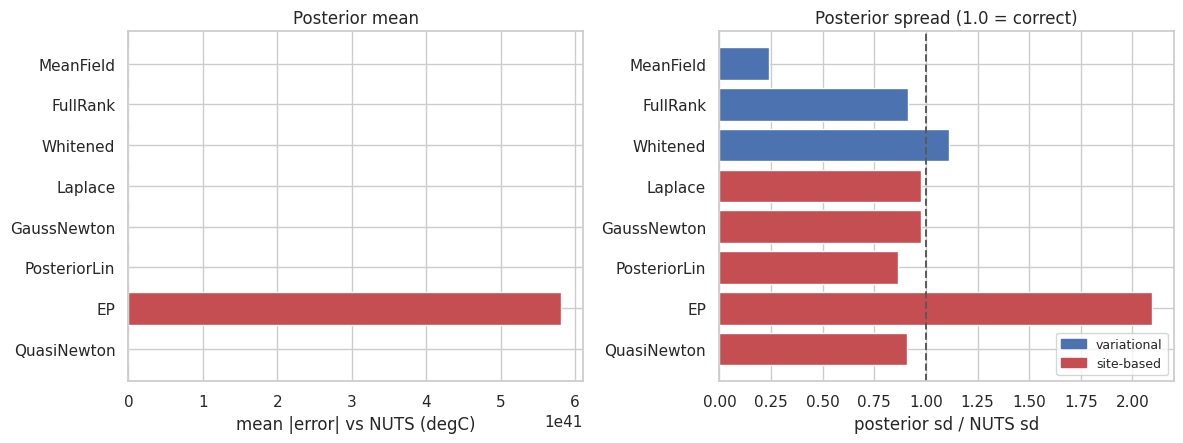

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
order = list(results)
colors = ["#4C72B0" if results[m]["family"] == "variational" else "#C44E52"
          for m in order]

err = [np.abs(results[m]["mean"] - ref_mean).mean() for m in order]
axes[0].barh(order, err, color=colors)
axes[0].set(xlabel="mean |error| vs NUTS (degC)", title="Posterior mean")

ratio = [(results[m]["sd"] / ref_sd).mean() for m in order]
axes[1].barh(order, ratio, color=colors)
axes[1].axvline(1.0, color="0.35", lw=1.4, ls="--")
axes[1].set(xlabel="posterior sd / NUTS sd", title="Posterior spread (1.0 = correct)")
for ax in axes:
    ax.invert_yaxis()
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="#4C72B0", label="variational"),
                        Patch(color="#C44E52", label="site-based")],
               loc="lower right", fontsize=9)
fig.tight_layout()
plt.show()

## The bounded tail, switched back on

Everything so far ran at $\xi=0$. Now put the fitted $\xi<0$ back and repeat —
the model regains its hard upper bound $\mu+\sigma/|\xi|$, and the two families
part company.

The reason is mechanical. The variational ELBO evaluates
$\mathbb{E}_{q(f_n)}[\log p(y_n \mid f_n)]$ by **Gauss-Hermite quadrature**,
which places nodes several standard deviations either side of the mean. Any node
low enough to put an observation above its upper bound contributes
$\log 0 = -\infty$, and one such node makes the whole ELBO infinite. The
site-based methods never integrate over that range: they work from local
derivatives at the current estimate, so a bound the data respects costs them
nothing.


In [11]:
lik_bounded = P.DistLikelihood(
    lambda f: GEV(loc=f + M0, scale=SIGMA, concentration=XI_FIT))

print(f"with xi = {XI_FIT:+.3f}, upper bound = location + {SIGMA / abs(XI_FIT):.1f} degC\n")

g = P.WhitenedGuide.init(S, scale=1.0, solver=SOLVER)
elbo_b = float(P.svgp_elbo(sparse, g, lik_bounded, X, y, integrator=integrator))
print(f"{'variational ELBO (Whitened)':32s} {elbo_b:>12.3f}"
      f"   <- {'unusable' if not np.isfinite(elbo_b) else 'ok'}")

for name, cls in STRATEGIES:
    try:
        cond = dense.condition_nongauss(lik_bounded, y, strategy=cls())
        m_b, v_b = cond.predict(X)
        ok = bool(np.all(np.isfinite(np.asarray(m_b))))
        print(f"{'site-based: ' + name:32s} {float(jnp.mean(m_b)) + M0:>12.3f}"
              f"   <- {'ok' if ok else 'failed'}")
    except Exception as exc:
        print(f"{'site-based: ' + name:32s} {'failed':>12s}   <- {type(exc).__name__}")

with xi = -0.205, upper bound = location + 9.5 degC



variational ELBO (Whitened)              -inf   <- unusable


site-based: Laplace                    40.223   <- ok


site-based: GaussNewton                40.223   <- ok


site-based: PosteriorLin                  nan   <- failed


site-based: EP                         40.160   <- ok


site-based: QuasiNewton                40.397   <- ok


## What to take away

**Gauss-Newton is the one to reach for.** It matched Laplace's answer exactly --
same mean error, same posterior spread -- in a quarter of the time, and both sat
closest to NUTS on the two things that matter. Nothing else was both accurate
and cheap.

**Mean-field's spread is the least trustworthy number here.** Its posterior
standard deviation came out at **0.24x** the NUTS reference: it is not merely
imprecise, it is confidently wrong, and any interval built on it would be four
times too narrow. Full-rank, which differs from it *only* by being allowed
off-diagonal terms, recovers 0.91x.

**A tighter ELBO did not mean a better posterior.** Whitened reached much the
best bound of the three guides (-350 against full-rank's -632) and trained in a
third of the time, yet full-rank beat it on both mean error and spread. The ELBO
measures the bound, not the marginals you actually report -- a useful reminder
when tuning a variational fit by loss alone.

**For a bounded tail, the site-based family is the only option.** With
$\xi<0$ restored, the variational ELBO is $-\infty$ before the optimiser takes
a step: Gauss-Hermite quadrature places nodes several standard deviations out,
any node low enough to put an observation above the upper bound
$\mu+\sigma/|\xi|$ contributes $\log 0$, and one such node poisons the whole
objective. The site-based methods never integrate over that range -- they work
from local derivatives -- so the bound costs them nothing. This is the honest
reason notebook 07's Laplace fit behaved better than 08's mean-field VI, and
nobody planned it.

**But no single method was robust across both settings.** EP diverged on the
unbounded problem while handling the bounded one; posterior linearisation did
exactly the reverse. Neither failure is subtle -- both produce numbers no one
would mistake for an answer -- but it does mean *check the method against your
own likelihood* rather than trusting a ranking like this one.

### A caution about reading this back into notebooks 08 and 09

It is tempting to conclude that mean-field explains their inflated return-level
intervals. It does not, at least not directly: mean-field here *under*-disperses
the latent field, which would make intervals too narrow, not too wide. Those
notebooks also infer $\sigma$ and $\xi$ rather than holding them fixed, and a
return level is a strongly non-linear function of all three. The likeliest
culprit is the shape and scale marginals, not the field -- which is worth its
own experiment rather than an assumption.

Two library issues surfaced while writing this, both worth fixing upstream
rather than working around:

1. `gaussx.safe_cholesky` uses a `while_loop`, which has no reverse-mode
   derivative -- this is what the shim at the top patches. It makes
   `MeanFieldGuide` and `FullRankGuide` untrainable through `svgp_elbo` as
   shipped.
2. `NaturalGuide` with `ConjugateVI` diverged at every damping we tried
   (1.0, 0.3, 0.1, 0.05), so it is absent from the table above rather than
   quietly reported as poor.

### Where this leads

The next notebooks in this section take up the other threads: **coregionalised**
$(\mu, \sigma, \xi)$ fields so the shape can borrow strength from the location
instead of floating free, and **pathwise sampling** so a return-level map
carries joint rather than marginal uncertainty.
